# UKCI Threshold Detector

Detects extreme and compound events across UKCI (UKCP for now) data for a chosen UK region.   
The ensemble gives a **range of projections** rather than a single answer, reflecting model uncertainty.Single ensemble members shouldn't be taken as truth, all members represent equally (is equally correct?) plausible projections. For this reason, ensemble means aren't a realistic 'middle of the road' projection of future climate change, as it can wash out variability.   
Not all members needs to agree on a trend for it to be considered valid, even a couple of members exhibiting a behaviour change (e.g.: increase in drought conditions by 2040) can be considered a significant likelihood of occuring. 

## What to do

**You only need to edit Cell 2.** All other cells run automatically from those settings. Work through the cells in order (Run All, or Shift+Enter cell by cell).

## Detection modes

The notebook supports three modes, controlled by the parameters in Cell 2:

| Mode | When to use | Key settings |
|---|---|---|
| **Single-variable** | One variable, one threshold | Set `THRESHOLD_2 = None` |
| **Bivariate: sequential** | Two variables that occur within a few days of each other (e.g. a dry spell *followed by* extreme rainfall) | Set `THRESHOLD_2`, `COMPOUND_MODE = 'sequential'` |
| **Bivariate: co-occurring** | Two variables that are simultaneously extreme (e.g. a heat extreme *during* a drought) | Set `THRESHOLD_2`, `COMPOUND_MODE = 'co-occurring'` |

In **sequential** mode a compound event is a cluster of extreme days drawn from *either* variable, where no two consecutive extreme days (from either series) are more than `DELT` days apart, and the cluster contains at least one extreme day from *each* variable.

In **co-occurring** mode a compound event requires at least one day where *both* variables are simultaneously extreme. Adjacent coincident days within `DELT` of each other are merged into a single event.

---

## Parameter reference

### Data sources
| Parameter | Description |
|---|---|
| `BASE_DIR` | Root directory that contains per-region sub-folders for **Variable 1**. |
| `FILENAME_PATTERN` | Filename template for Variable 1. Use `{ensemble}` and `{region}` as placeholders, e.g. `'p110{ensemble}_{region}.nc'`. |
| `BASE_DIR_2` | Root directory for **Variable 2**. Set to `None` to load both variables from the same files as Variable 1. |
| `FILENAME_PATTERN_2` | Filename template for Variable 2. Set to `None` to use the same template as Variable 1. |

### Domain
| Parameter | Description |
|---|---|
| `REGION` | The UK region to analyse in Steps 2–4. Must match a sub-folder name inside `BASE_DIR`. |
| `ENSEMBLES` | List of ensemble member IDs to process. |
| `ALL_REGIONS` | Full list of UK regions used in the UK-wide (Step 5) and regional (Step 6) plots. |

### Season
| Parameter | Description |
|---|---|
| `LOWER_MONTH` | First month of the season to extract (inclusive, 1–12). |
| `HIGHER_MONTH` | Last month of the season to extract (inclusive, 1–12). Default `6–9` = JJAS (summer). |

### Variable 1 — threshold
| Parameter | Description |
|---|---|
| `THRESHOLD` | The threshold value that defines an extreme event for Variable 1. Units should match the data (e.g. mm/hr, °C). |
| `DIRECTION` | `'above'` flags values *greater than* the threshold (e.g. heavy rain, heat). `'below'` flags values *less than* the threshold (e.g. drought, cold). |
| `N_CONSECUTIVE` | Number of consecutive days that must exceed the threshold to constitute a flagged event. `1` means any single exceedance counts. Increase this for events like prolonged dry spells. |

### Variable 2 — threshold (bivariate only)
These work identically to the Variable 1 settings above, but are applied to the second timeseries. Set `THRESHOLD_2 = None` to run in single-variable mode.

| Parameter | Description |
|---|---|
| `THRESHOLD_2` | Threshold for Variable 2. `None` disables bivariate detection. |
| `DIRECTION_2` | `'above'` or `'below'`, as above. |
| `N_CONSECUTIVE_2` | Consecutive days required for Variable 2. |

### Compound detection
These settings apply to all three modes.

| Parameter | Description |
|---|---|
| `COMPOUND_MODE` | `'sequential'` or `'co-occurring'`. Only relevant when `THRESHOLD_2` is set. |
| `DELT` | Maximum gap in days between consecutive extreme days (from either variable in bivariate mode) that still allows them to be grouped into a single compound event. Larger values merge more spread-out clusters. |
| `MIN_DURATION` | Minimum number of extreme days required for a cluster to be counted as a compound event. Filters out isolated single-day spikes (single-variable) or single co-occurrence days (bivariate). |
| `TAU` | Coincidence interval (days) used in Event Coincidence Analysis (Step not shown by default). Two events coincide if they fall within `tau` days of each other. |

### Plotting
| Parameter | Description |
|---|---|
| `CMAP` | Matplotlib colormap name used in the Hovmöller plots (e.g. `'Blues'`, `'YlOrRd'`). More examples here: https://matplotlib.org/stable/users/explain/colors/colormaps.html |
| `ROLLING_WINDOW` | Window size (years) for the rolling mean in the ensemble-spread plot (Step 3). |
| `DATA_START_YEAR` | Calendar year that index 0 of the loaded timeseries corresponds to. Used to assign a `year` label to each detected event. |

---

## Output

Each step produces a different view of the same compound-event signal:

- **Step 1** — loads the raw timeseries for every ensemble member.
- **Step 2** — flags extreme days and detects compound events for every member.
- **Step 3** — plots the ensemble *spread* (mean ± min/max band) of compound-event counts per year.
- **Step 4** — Hovmöller plot: every ensemble member × every year for the chosen region.
- **Step 5** — UK-wide Hovmöller: a day is counted if *any* region had a compound event on that day.
- **Step 6** — Regional Hovmöller: ensemble-mean compound extreme days per region per year.


## Example use cases

The parameter cell below drives all three detection modes. Copy one of these
configurations into it as a starting point.

**1. Single-variable: clustered extreme rainfall (the paper's method)**
```
THRESHOLD_1=20, DIRECTION_1='above', N_CONSECUTIVE_1=1, MIN_DAYS_1=None
THRESHOLD_2=None                      # single-variable mode
MIN_DURATION=2                        # >= 2 extreme days per event
SEASON_START, SEASON_LENGTH = 6, 4    # June-September
```

**2. Single-variable: heatwaves clustering (tasmax files)**
```
FILENAME_PATTERN='tasmax{ensemble}_{region}.nc'
THRESHOLD_1=28, DIRECTION_1='above', N_CONSECUTIVE_1=3   # 3 hot days in a row = one heatwave
THRESHOLD_2=None, MIN_DURATION=2      # >= 2 heatwaves close together
```

**3. Sequential: drought then downpour (same rainfall file, both variables)**
"a 20-day drought with at least 19 dry days, followed by 3 days of rainfall":
```
THRESHOLD_1=1,  DIRECTION_1='below', N_CONSECUTIVE_1=20, MIN_DAYS_1=19   # tolerant dry spell
THRESHOLD_2=1,  DIRECTION_2='above', N_CONSECUTIVE_2=1,  MIN_DAYS_2=None # rain days, flagged daily
COMPOUND_MODE='sequential'
MIN_DURATION_1=1, MIN_DURATION_2=3    # >= 1 drought flag AND >= 3 rain days per event
```
(Equivalent alternative: `N_CONSECUTIVE_2=3` to demand 3 *consecutive* rain
days as one flag, with `MIN_DURATION_2=1`.)

**4. Sequential, two files: dry spell then hot spell**
```
BASE_DIR_2='/path/to/tasmax', FILENAME_PATTERN_2='tasmax{ensemble}_{region}.nc'
THRESHOLD_1=1,  DIRECTION_1='below', N_CONSECUTIVE_1=10   # 10-day dry spell in precip
THRESHOLD_2=28, DIRECTION_2='above', N_CONSECUTIVE_2=3    # 3-day hot spell in tasmax
COMPOUND_MODE='sequential', MIN_DURATION_1=1, MIN_DURATION_2=1
```

**5. Co-occurring: compound hot-and-dry days**
```
BASE_DIR_2='/path/to/tasmax', FILENAME_PATTERN_2='tasmax{ensemble}_{region}.nc'
THRESHOLD_1=1,  DIRECTION_1='below', N_CONSECUTIVE_1=1    # dry day
THRESHOLD_2=28, DIRECTION_2='above', N_CONSECUTIVE_2=1    # hot day
COMPOUND_MODE='co-occurring'
MIN_DURATION=2                        # >= 2 hot-AND-dry days per event
```

**6. Wrapped season: winter storm clustering (October through February)**
```
SEASON_START, SEASON_LENGTH = 10, 5   # Oct-Feb, wraps the calendar year;
                                      # season-year is labelled by the START year
THRESHOLD_1=20, DIRECTION_1='above', N_CONSECUTIVE_1=1, THRESHOLD_2=None
```


In [10]:
# ============================================================
# USER PARAMETERS — edit this cell only
# ============================================================

# --- Data sources ---
# Configure file paths for both variables here.
# Variable 2 defaults to None, which means it re-uses Variable 1's values.
BASE_DIR           = '/home/users/elena.dauster/Documents/python/CoinCalc/data_for_ECA'
FILENAME_PATTERN   = 'p110{ensemble}_{region}.nc'    # Variable 1 filename template
BASE_DIR_2         = None    # e.g. '/path/to/temperature/data' — None = same as BASE_DIR
FILENAME_PATTERN_2 = None    # e.g. 'tasmax{ensemble}_{region}.nc' — None = same as FILENAME_PATTERN

REGION = 'Wales'   # choose one region

ENSEMBLES = ['0000','1113','1554','1649','1843','1935','2123','2242','2305','2335','2491','2868']

# All UK regions (used for the UK-wide Hovmöller in Step 5)
ALL_REGIONS = [
    'East_Midlands', 'East_Scotland', 'East_of_England', 'North_East_England',
    'North_Scotland', 'North_West_England', 'Northern_Ireland', 'South_East_England',
    'South_West_England', 'Wales', 'West_Midlands', 'West_Scotland', 'Yorkshire_and_Humber',]

# --- Season (modular) ---
# Start month + duration in months, wrapping the calendar year if needed:
#   (6, 4)  = June -> September (JJAS)
#   (8, 2)  = August -> September
#   (10, 5) = October -> February (wraps; the season-year label is the
#             year the season STARTED in, so Oct 1980 - Feb 1981 = 1980)
SEASON_START  = 6
SEASON_LENGTH = 4

# --- Variable 1 event definition ---
THRESHOLD_1     = 20          # threshold for event detection
DIRECTION_1     = 'above'    # 'above' or 'below' the threshold
N_CONSECUTIVE_1 = 1          # window length (days) to flag one event
MIN_DAYS_1      = None       # min extreme days within the window
                             # (None = all N required; e.g. N=20, MIN_DAYS=19
                             #  = a 20-day drought with >= 19 dry days)

# --- Variable 2 event definition (set THRESHOLD_2 = None for single-variable mode) ---
# File paths for Variable 2 are set above (BASE_DIR_2 / FILENAME_PATTERN_2).
THRESHOLD_2     =20          # set to None to disable two-variable modes
DIRECTION_2     = 'above'    # 'above' or 'below'
N_CONSECUTIVE_2 = 1        # window length (days) for variable 2
MIN_DAYS_2      = None       # tolerance for variable 2 (None = all N required)

# --- Compound mode (two-variable only) ---
# 'sequential'   : extremes from both variables within the linkage window of
#                  each other (e.g. dry spell then extreme rain)
# 'co-occurring' : both variables extreme on the same day(s)
#                  (e.g. heat + drought)
COMPOUND_MODE = 'sequential'

# --- Compound detection ---
# Flagged days link when their gap g satisfies TAU <= g <= TAU + DELT within
# one season — the MAX linkage gap is TAU + DELT days, and events never pair
# across a season boundary.
DELT = 4                     # ECA coincidence window
TAU  = 1                     # ECA minimum lag (must be >= 1)

# Minimum flagged days per compound event — consistent across modes:
MIN_DURATION   = 2           # single-variable: total flagged days;
                             # co-occurring: coincident (both-extreme) days
MIN_DURATION_1 = 1           # sequential: min variable-1 flags per event
MIN_DURATION_2 = 1           # sequential: min variable-2 flags per event

# --- Plotting ---
CMAP           = 'Blues'
ROLLING_WINDOW = 6
FIGURES_DIR    = '../outputs/figures'   # created automatically if missing

# ============================================================
if THRESHOLD_2 is None:
    _mode = "single-variable"
else:
    _mode = f"bivariate ({COMPOUND_MODE})"
print(f"Region: {REGION} | {len(ENSEMBLES)} members | {len(ALL_REGIONS)} UK regions | "
      f"season ({SEASON_START},{SEASON_LENGTH}) | mode: {_mode}")


Region: Wales | 12 members | 13 UK regions | season (6,4) | mode: bivariate (sequential)


In [11]:
import sys, os, warnings
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# keep the notebook output clean: silence FutureWarnings from dependencies
# (e.g. iris's legacy date-precision notice; the loader also opts in to the
# new precision at the source)
warnings.filterwarnings('ignore', category=FutureWarning)

from threshold_detector import (
    flag_extreme_events,
    detect_compound_events,
    detect_compound_events_bivariate,
    detect_compound_events_coincident,
    season_year_labels,
    load_region_ensemble,
    summarise_ensemble_events,
    run_eca,
    summary_table,
    plot_ensemble_spread,
    plot_ensemble_hovmoller,
    plot_duration_and_counts,
    save_figure,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Imports successful.")


Imports successful.


## Step 1: Load the ensemble for the chosen region


In [12]:
ensemble_data = load_region_ensemble(
    base_dir=BASE_DIR,
    region=REGION,
    ensembles=ENSEMBLES,
    season_start=SEASON_START,
    season_length=SEASON_LENGTH,
    filename_pattern=FILENAME_PATTERN,
    return_time=True,            # (data, years, months) per member —
)                                # needed for season blocking + year labels

print(f"Loaded {len(ensemble_data)} members for {REGION}.")
for ens, (arr, yrs, mons) in ensemble_data.items():
    print(f"  {ens}: {len(arr)} days, {yrs.min()}–{yrs.max()}")

# Load Variable 2 separately only if its source differs from Variable 1.
# Otherwise both variables are derived from the same timeseries.
if THRESHOLD_2 is not None and (BASE_DIR_2 is not None or FILENAME_PATTERN_2 is not None):
    ensemble_data_2 = load_region_ensemble(
        base_dir=BASE_DIR_2 or BASE_DIR,
        region=REGION,
        ensembles=ENSEMBLES,
        season_start=SEASON_START,
        season_length=SEASON_LENGTH,
        filename_pattern=FILENAME_PATTERN_2 or FILENAME_PATTERN,
        return_time=True,
    )
    print(f"\nLoaded Variable 2 for {len(ensemble_data_2)} members.")
else:
    ensemble_data_2 = ensemble_data


Loaded 12 members for Wales.
  0000: 12000 days, 1981–2080
  1113: 12000 days, 1981–2080
  1554: 12000 days, 1981–2080
  1649: 12000 days, 1981–2080
  1843: 12000 days, 1981–2080
  1935: 12000 days, 1981–2080
  2123: 12000 days, 1981–2080
  2242: 12000 days, 1981–2080
  2305: 12000 days, 1981–2080
  2335: 12000 days, 1981–2080
  2491: 12000 days, 1981–2080
  2868: 12000 days, 1981–2080


## Step 2: Detect events for every member

Each member is processed independently, then pooled so the ensemble range can be seen.
If this prints mostly zeros, see the troubleshooting notes at the bottom of the notebook.


In [13]:
events_by_member = {}

for ensemble, (data, years, months) in ensemble_data.items():
    binary_1 = flag_extreme_events(
        data, threshold=THRESHOLD_1, direction=DIRECTION_1,
        N=N_CONSECUTIVE_1, min_days=MIN_DAYS_1)
    if THRESHOLD_2 is not None:
        data_2 = ensemble_data_2.get(ensemble, (data, years, months))[0]
        binary_2 = flag_extreme_events(
            data_2, threshold=THRESHOLD_2, direction=DIRECTION_2,
            N=N_CONSECUTIVE_2, min_days=MIN_DAYS_2)
        if COMPOUND_MODE == 'co-occurring':
            events = detect_compound_events_coincident(
                binary_1, binary_2, delT=DELT, tau=TAU,
                min_duration=MIN_DURATION,
                years=years, months=months,
                season_start=SEASON_START, season_length=SEASON_LENGTH)
        else:
            events = detect_compound_events_bivariate(
                binary_1, binary_2, delT=DELT, tau=TAU,
                min_duration_1=MIN_DURATION_1, min_duration_2=MIN_DURATION_2,
                years=years, months=months,
                season_start=SEASON_START, season_length=SEASON_LENGTH)
    else:
        events = detect_compound_events(
            binary_1, delT=DELT, tau=TAU, min_duration=MIN_DURATION,
            years=years, months=months,
            season_start=SEASON_START, season_length=SEASON_LENGTH)

    # Attach the season-year (for wrapping seasons, the year the season
    # STARTED in — covers every valid year exactly once)
    if len(events) > 0:
        syear = season_year_labels(years, months, SEASON_START)
        events['year'] = syear[events['start_idx'].values]
        events['ensemble'] = ensemble
    events_by_member[ensemble] = events

    print(f"  {ensemble}: {len(events)} compound events")

# Combine into one long DataFrame for plotting functions that need it
all_events = pd.concat(
    [df for df in events_by_member.values() if len(df) > 0],
    ignore_index=True)
print(f"\nTotal compound events across ensemble: {len(all_events)}")


  0000: 202 compound events
  1113: 242 compound events
  1554: 195 compound events
  1649: 100 compound events
  1843: 141 compound events
  1935: 168 compound events
  2123: 173 compound events
  2242: 200 compound events
  2305: 217 compound events
  2335: 82 compound events
  2491: 210 compound events
  2868: 252 compound events

Total compound events across ensemble: 2182


## Step 3: Ensemble spread - the projection range

The key ensemble output: the mean with a min-max band across members. Read the **band**, not the line. The band is the range of plausible futures; the line is only its centre.


   year      mean  min  max  median  n_members
0  1981  1.166667  0.0  4.0     1.0          7
1  1982  1.166667  0.0  3.0     1.0          8
2  1983  0.666667  0.0  2.0     0.5          6
3  1984  1.333333  0.0  3.0     1.0         10
4  1985  1.000000  0.0  2.0     1.0          8


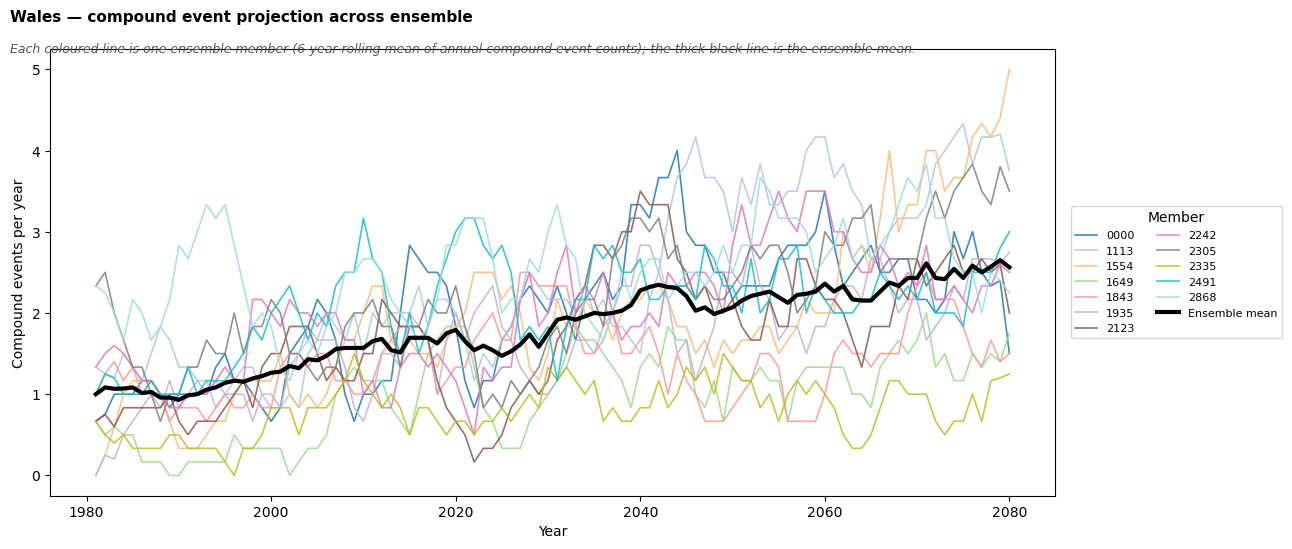

In [14]:
summary = summarise_ensemble_events(events_by_member)
print(summary.head())

# Each ensemble member is its own coloured line; the ensemble mean is the
# thick black line over them.
fig = plot_ensemble_spread(
    events_by_member,
    rolling_window=ROLLING_WINDOW,
    title=f'{REGION} — compound event projection across ensemble')

save_figure(fig, f'{FIGURES_DIR}/{REGION}_ensemble_spread.png')
plt.show()


## Step 4: Hovmoller - every member over time

Two figures: **number of events** per member per year, and **total extreme days** per member
per year. Members are ordered by total event count, so a trend appearing in only a few members
is still visible rather than being averaged away.


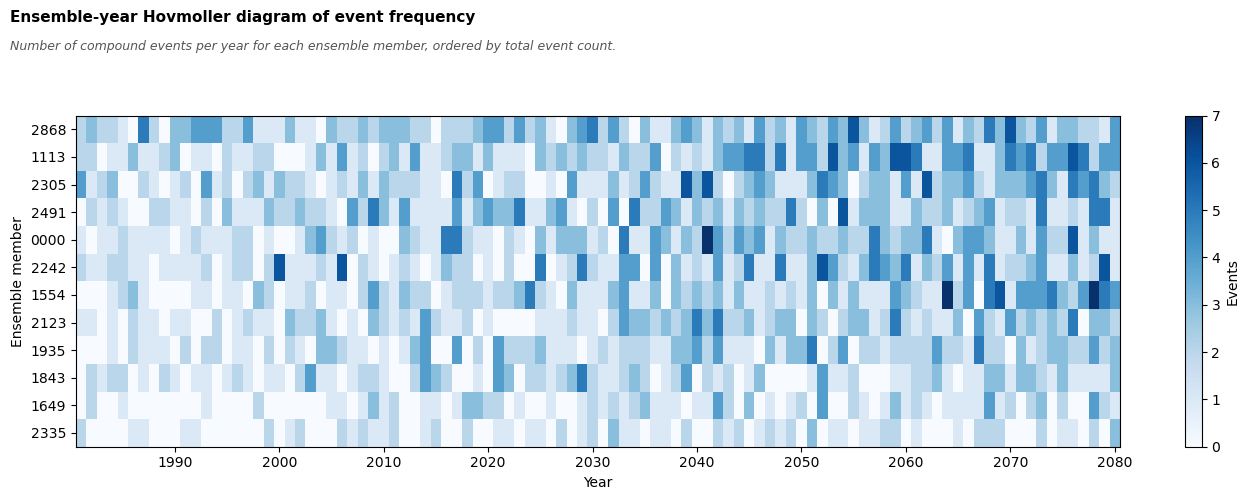

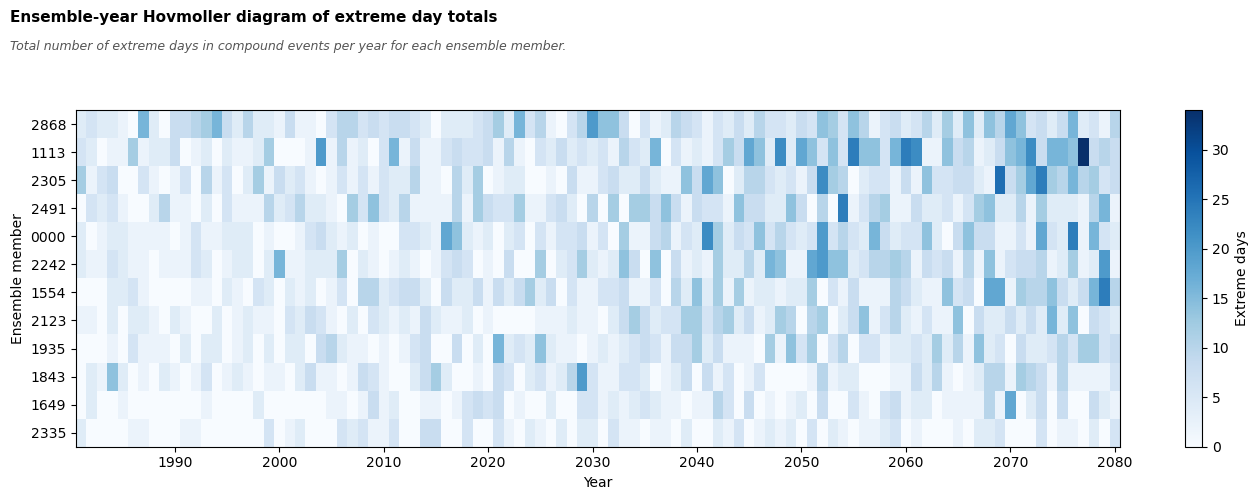

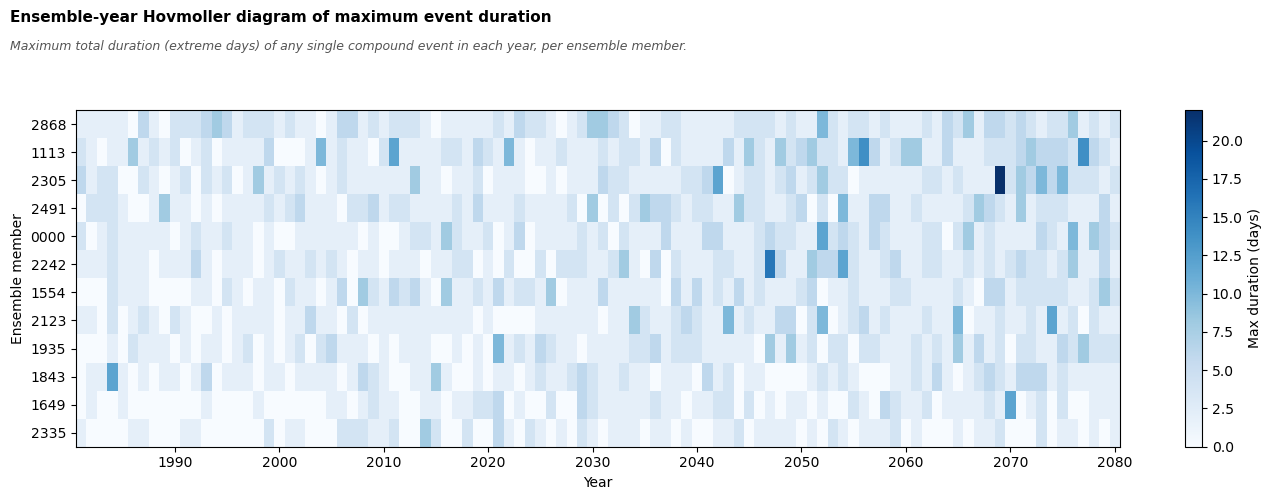

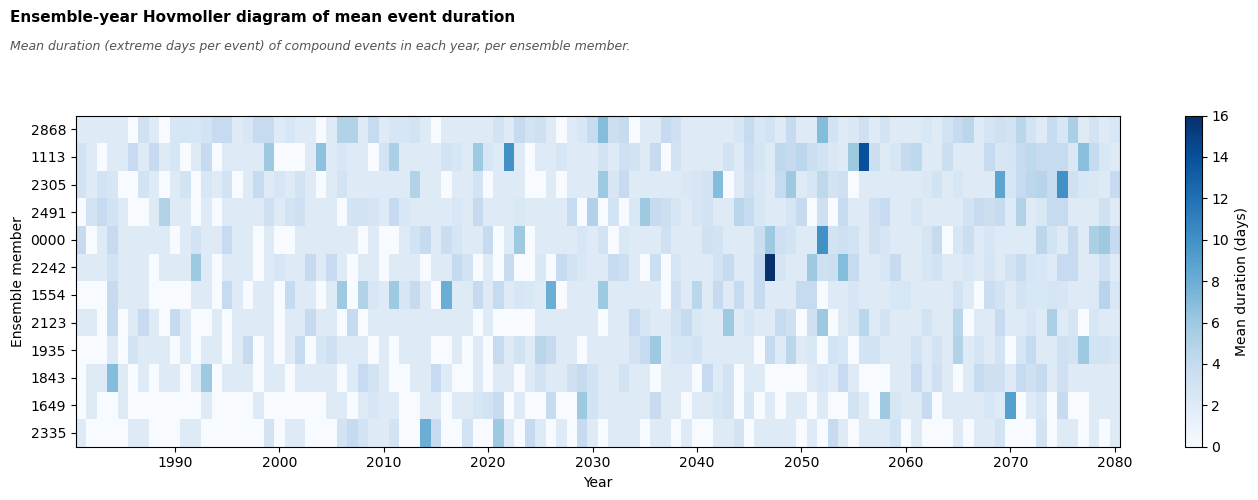

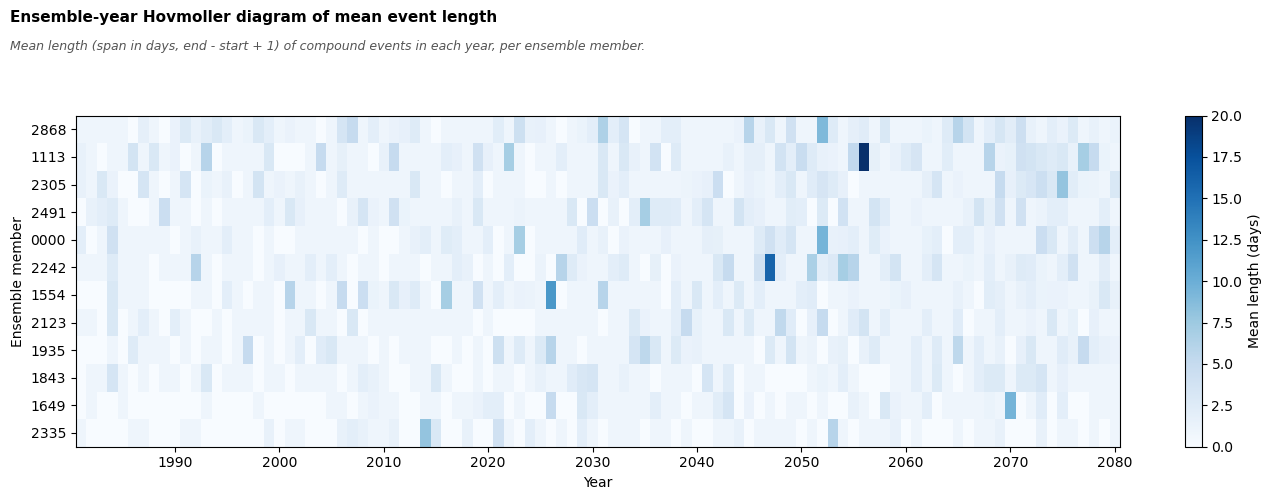

In [15]:
# Five Hovmöller panels: event counts, extreme-day totals, max event
# duration, mean event duration, mean event length
hov = plot_ensemble_hovmoller(
    all_events,
    ensemble_col='ensemble',
    year_col='year',
    duration_col='n_extreme_days',
    length_col='length',
    cmap=CMAP,)

for name, fig in hov.items():
    save_figure(fig, f'{FIGURES_DIR}/{REGION}_hovmoller_{name}.png')
plt.show()


## Step 5: All regions

The next cell loads every region for every member **once** and caches the result. Both Step 5
and Step 6 read from that cache, so the data is not loaded twice.

This is the slowest cell in the notebook: it reads
`len(ALL_REGIONS) x len(ENSEMBLES)` files. Re-run the later cells freely without re-running this one.


In [16]:
uk_events_by_member = {}
uk_years = uk_months = None      # calendar axes, shared by all regions

for ensemble in ENSEMBLES:
    compound_idx_union = set()

    for region in ALL_REGIONS:
        try:
            region_data, r_years, r_months = load_region_ensemble(
                base_dir=BASE_DIR, region=region,
                ensembles=[ensemble],
                season_start=SEASON_START, season_length=SEASON_LENGTH,
                filename_pattern=FILENAME_PATTERN,
                return_time=True,
            )[ensemble]
            if uk_years is None:
                uk_years, uk_months = r_years, r_months

            binary_1 = flag_extreme_events(
                region_data, threshold=THRESHOLD_1, direction=DIRECTION_1,
                N=N_CONSECUTIVE_1, min_days=MIN_DAYS_1)

            if THRESHOLD_2 is not None:
                if BASE_DIR_2 is not None or FILENAME_PATTERN_2 is not None:
                    region_data_2 = load_region_ensemble(
                        base_dir=BASE_DIR_2 or BASE_DIR, region=region,
                        ensembles=[ensemble],
                        season_start=SEASON_START, season_length=SEASON_LENGTH,
                        filename_pattern=FILENAME_PATTERN_2 or FILENAME_PATTERN,
                        return_time=True,
                    ).get(ensemble, (region_data, r_years, r_months))[0]
                else:
                    region_data_2 = region_data

                binary_2 = flag_extreme_events(
                    region_data_2, threshold=THRESHOLD_2, direction=DIRECTION_2,
                    N=N_CONSECUTIVE_2, min_days=MIN_DAYS_2)
                if COMPOUND_MODE == 'co-occurring':
                    region_events = detect_compound_events_coincident(
                        binary_1, binary_2, delT=DELT, tau=TAU,
                        min_duration=MIN_DURATION,
                        years=r_years, months=r_months,
                        season_start=SEASON_START, season_length=SEASON_LENGTH)
                else:
                    region_events = detect_compound_events_bivariate(
                        binary_1, binary_2, delT=DELT, tau=TAU,
                        min_duration_1=MIN_DURATION_1,
                        min_duration_2=MIN_DURATION_2,
                        years=r_years, months=r_months,
                        season_start=SEASON_START, season_length=SEASON_LENGTH)
            else:
                region_events = detect_compound_events(
                    binary_1, delT=DELT, tau=TAU, min_duration=MIN_DURATION,
                    years=r_years, months=r_months,
                    season_start=SEASON_START, season_length=SEASON_LENGTH)

            # a UK-wide compound day = any region's compound-event day
            for _, row in region_events.iterrows():
                compound_idx_union.update(
                    range(int(row['start_idx']), int(row['end_idx']) + 1))
        except Exception as e:
            print(f"  skip {region} / {ensemble}: {e}")

    if uk_years is None:
        continue
    n_days = len(uk_years)
    union_compound_binary = np.zeros(n_days, dtype=int)
    for idx in compound_idx_union:
        if idx < n_days:
            union_compound_binary[idx] = 1

    # re-detect on the UK-wide union series (same season blocking!)
    events = detect_compound_events(
        union_compound_binary, delT=DELT, tau=TAU, min_duration=MIN_DURATION,
        years=uk_years, months=uk_months,
        season_start=SEASON_START, season_length=SEASON_LENGTH)

    if len(events) > 0:
        syear = season_year_labels(uk_years, uk_months, SEASON_START)
        events['year'] = syear[events['start_idx'].values]
        events['ensemble'] = ensemble
    uk_events_by_member[ensemble] = events
    print(f"  {ensemble}: {len(events)} UK-wide compound events")

uk_all_events = pd.concat(
    [df for df in uk_events_by_member.values() if len(df) > 0],
    ignore_index=True)
print(f"\nTotal UK-wide compound events: {len(uk_all_events)}")


  0000: 253 UK-wide compound events
  1113: 318 UK-wide compound events
  1554: 305 UK-wide compound events
  1649: 144 UK-wide compound events
  1843: 193 UK-wide compound events
  1935: 255 UK-wide compound events
  2123: 255 UK-wide compound events
  2242: 290 UK-wide compound events
  2305: 326 UK-wide compound events
  2335: 119 UK-wide compound events
  2491: 297 UK-wide compound events
  2868: 365 UK-wide compound events

Total UK-wide compound events: 3120


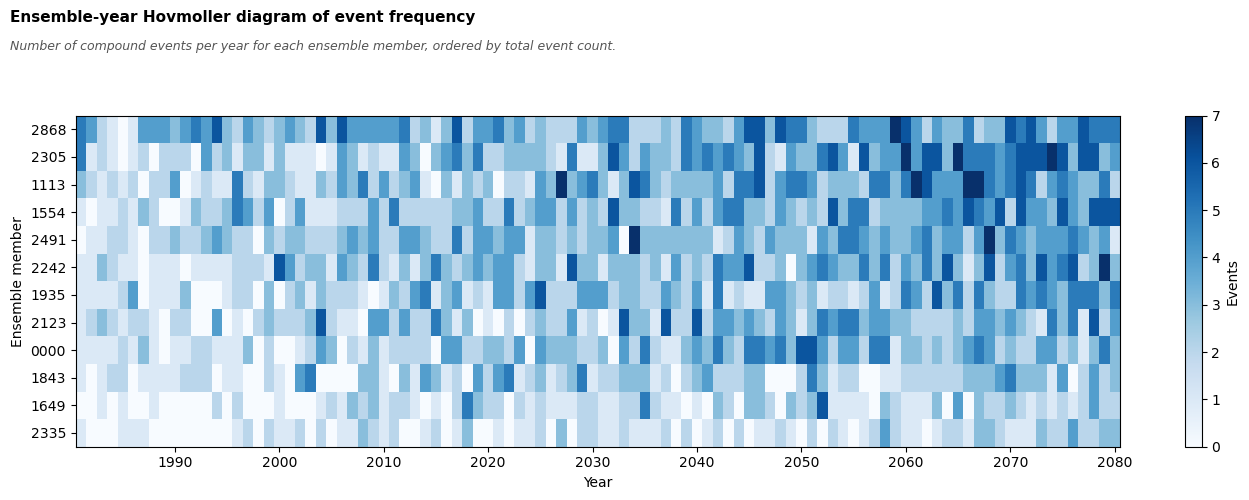

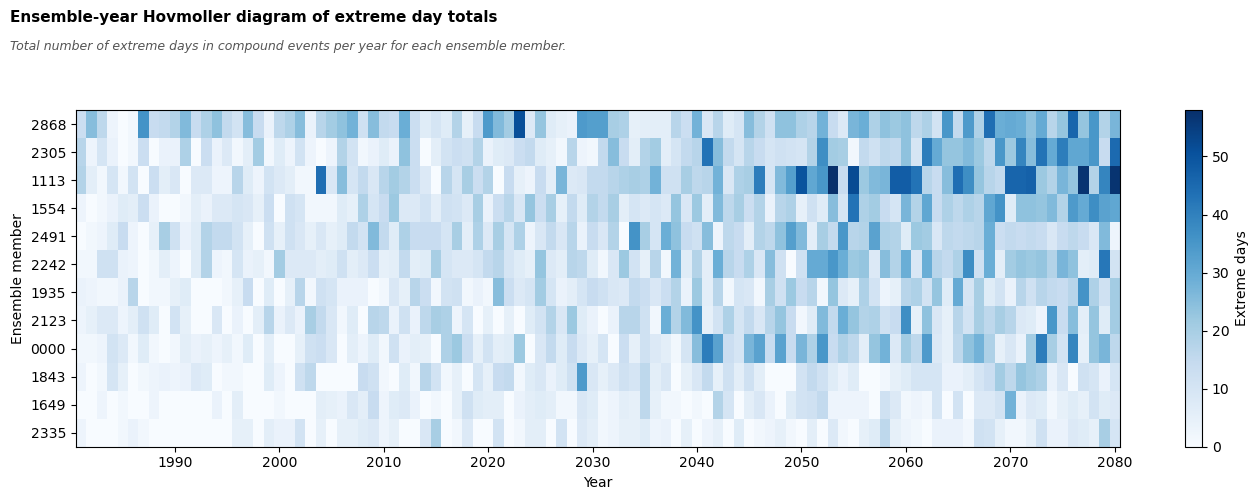

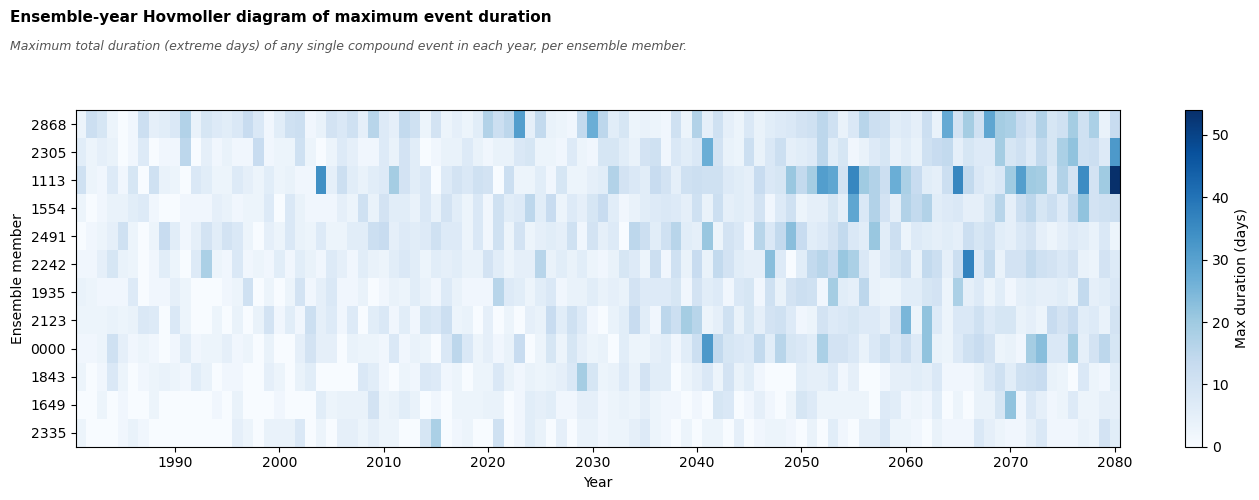

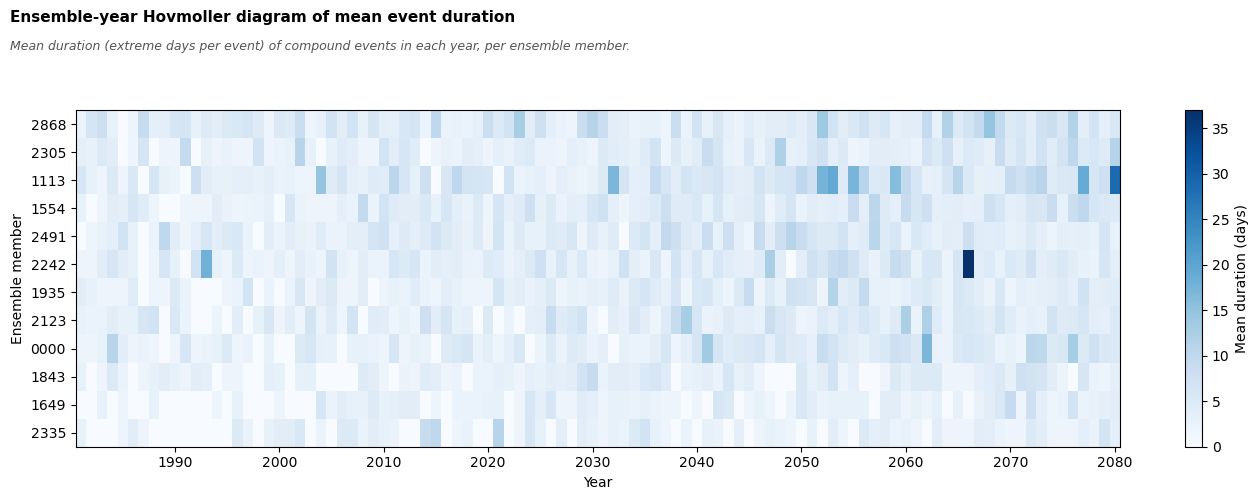

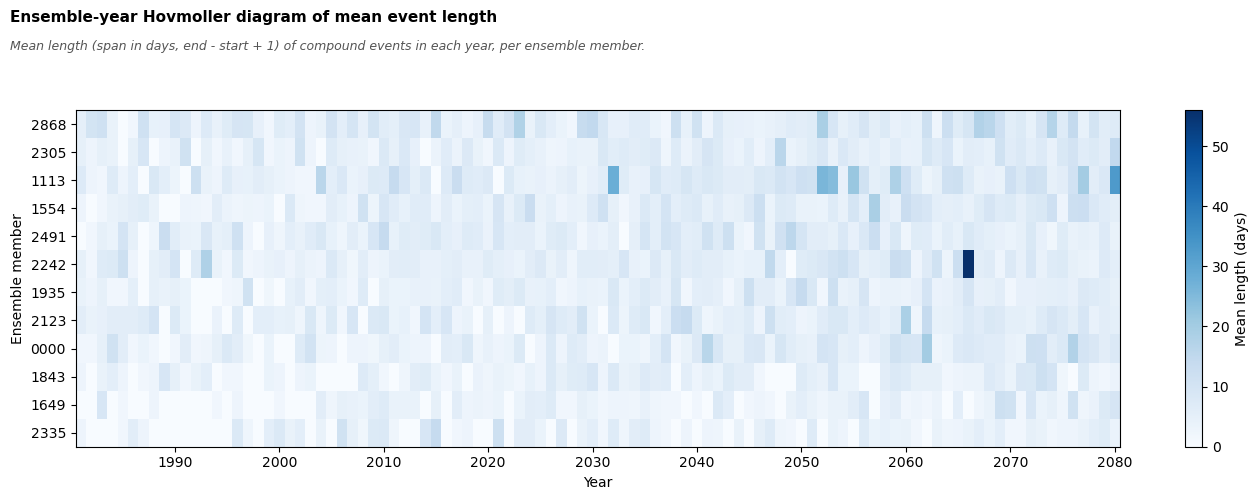

In [18]:
uk_hov = plot_ensemble_hovmoller(
    uk_all_events,
    ensemble_col='ensemble',
    year_col='year',
    duration_col='n_extreme_days',
    length_col='length',
    cmap=CMAP,)
for name, fig in uk_hov.items():
    save_figure(fig, f'{FIGURES_DIR}/UK_wide_hovmoller_{name}.png')
plt.show()


## Step 6: Regional comparison

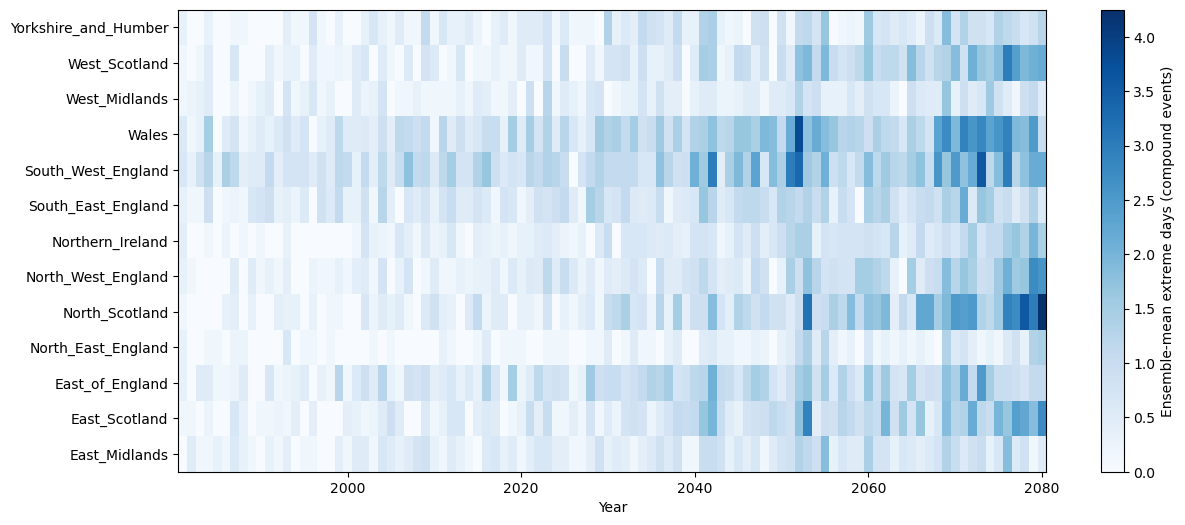

In [19]:
# For each region, compute ensemble-mean extreme days in compound events per year
region_year_matrix = {}

for region in ALL_REGIONS:
    member_counts = {}
    for ensemble in ENSEMBLES:
        try:
            data, yrs, mons = load_region_ensemble(
                base_dir=BASE_DIR, region=region, ensembles=[ensemble],
                season_start=SEASON_START, season_length=SEASON_LENGTH,
                filename_pattern=FILENAME_PATTERN, return_time=True,
            )[ensemble]
            binary = flag_extreme_events(
                data, threshold=THRESHOLD_1, direction=DIRECTION_1,
                N=N_CONSECUTIVE_1, min_days=MIN_DAYS_1)
            ev = detect_compound_events(
                binary, delT=DELT, tau=TAU, min_duration=MIN_DURATION,
                years=yrs, months=mons,
                season_start=SEASON_START, season_length=SEASON_LENGTH)
            if len(ev) > 0:
                syear = season_year_labels(yrs, mons, SEASON_START)
                ev['year'] = syear[ev['start_idx'].values]
                member_counts[ensemble] = ev.groupby('year')['n_extreme_days'].sum()
        except Exception as e:
            print(f"  skip {region} / {ensemble}: {e}")
    if member_counts:
        region_year_matrix[region] = pd.DataFrame(member_counts).fillna(0).mean(axis=1)

region_df = pd.DataFrame(region_year_matrix).T.fillna(0)   # regions x years

fig, ax = plt.subplots(figsize=(14, 6))
c = ax.pcolormesh(region_df.columns, np.arange(len(region_df)), region_df.values,
                  shading='nearest', cmap=CMAP)
ax.set_yticks(np.arange(len(region_df)))
ax.set_yticklabels(region_df.index)
ax.set_xlabel('Year')
fig.colorbar(c, ax=ax, label='Ensemble-mean extreme days (compound events)')
save_figure(fig, f'{FIGURES_DIR}/regional_hovmoller.png')
plt.show()


---

# Extending the detector

Everything above is demostration. The code is in `threshold_detector/`, so any piece can
be swapped without touching the notebook.

### Where things live

| File | Contains |
|---|---|
| `detector.py` | Flagging, compound detection, segmentation, aggregation |
| `plotting.py` | All figures. Every label is a keyword argument |
| `coincidence.py` | Event Coincidence Analysis wrappers (needs the ECA repo) |

### The two contracts

**1. A flagging function** takes a timeseries and returns a binary array of the same length,
where `1` marks an extreme day.

```python
binary = flag_extreme_events(data, threshold=20, N=1, direction='above')
```

Replace this to define "extreme" differently - a percentile
(`flag_extreme_events_percentile`), a rolling accumulation, a rate of change. Anything
returning a same-length binary array will work with everything downstream.

**2. A detection function** takes one or two binary arrays and returns one row per event:

| Column | Meaning |
|---|---|
| `start_idx`, `end_idx` | Event bounds, as positions in the input array (inclusive) |
| `length` | `end_idx - start_idx + 1`, the span in days |
| `n_extreme_days` | Extreme days the event actually contains |
| `n_extreme_days_1`, `n_extreme_days_2` | Per-variable counts (bivariate, sequential) |
| `n_coincident_days` | Days where both were extreme (co-occurring) |
| `n_sequential_days` | Trigger days (sequential) |
| `year`, `ensemble` | Added by this notebook, not the detector |
| `n_regions`, `regions` | Added by `detect_multiregion_events` |

Anything returning `start_idx`, `end_idx`, `length` and `n_extreme_days` will plot correctly.

### If you write your own detector

- **Wrap it in `detect_by_segment`** so it cannot merge events across a seasonal gap.
- **Return indices, not dates.** The notebook converts indices to years using the file's own
  time coordinate; returning dates directly would bypass that.
- **Return an empty DataFrame with the right columns** when nothing is found, so downstream
  cells do not raise on a missing column.

### Getting at the data directly

Every intermediate object is a plain numpy array or pandas DataFrame:

```python
all_events                    # every event, chosen region, all members
uk_all_events                 # UK-wide events, with n_regions and regions
events_by_member['0000']      # one member
region_results[('Wales','0000')]['mask']    # daily binary mask
summary                       # per-year mean/min/max across the ensemble

all_events.to_csv('events.csv', index=False)
long_events = all_events[all_events['length'] >= 20]
```

---

# Assumptions and things to watch

| Watch out for | Why | What to do |
|---|---|---|
| **`MIN_DURATION` vs `MIN_TRIGGER_DAYS`** | In single-variable and co-occurring modes, `MIN_DURATION` counts extreme days. In sequential mode the filter is `MIN_TRIGGER_DAYS`, counting **trigger days** - and triggers are rare, so most real events have exactly one. | Leave `MIN_TRIGGER_DAYS = 1`. To keep only long events, filter on `length` instead. The detector warns if the setting discards everything. |
| **`DELT` does two jobs** | Within a region it merges nearby extreme days. In Step 5 it also decides how many days apart two *regions* can be and still count as one UK episode. | Raising `DELT` widens events and makes UK-wide events more likely. |
| **Seasons are kept apart** | JJAS years sit next to each other in the array; without the guard, September and the following June would merge. | Handled automatically. Preserve it in any custom detector by using `detect_by_segment`. |
| **Events are labelled by their START year** | An event spanning a year boundary counts once, in the year it began. Within a single season this cannot happen. | Only relevant if you set `LOWER_MONTH`/`HIGHER_MONTH` to span a new year, such as winter months. |
| **Ensemble means hide variability** | Step 6 uses a mean for regional comparison. It will look calmer than any individual member. | Judge uncertainty from Steps 3 and 4, not Step 6. |
| **Failed loads are skipped, not fatal** | A missing file prints a warning and continues, so a partial ensemble can silently look like a real result. | Check the loaded/failed counts printed by Steps 1 and 5. |

### If you get no events or the data looks funny

Work down in this order:

1. **Is anything flagged as extreme at all?** Check the threshold direction and value against your data's units.
2. **Is `N_CONSECUTIVE` too strict?** Requiring many consecutive days is far more demanding than it appears.
3. **Is the duration filter too strict?** `MIN_DURATION` in single/co-occurring mode; `MIN_TRIGGER_DAYS` in sequential.
4. **Sequential only: is `TAU` too short?** Variable 2 must follow Variable 1 within `TAU` days.
5. **Step 5 only: is `MIN_REGIONS` too high?** Set it to 1 to check whether regional events exist at all.
